In [33]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [5]:
DATA_DIR = Path("../data/raw")
CSV_PATH = DATA_DIR / "driver_imgs_list.csv"

In [6]:
df = pd.read_csv(CSV_PATH)
df.head()

,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [7]:
df.shape

(22424, 3)

In [8]:
df.columns

Index(['subject', 'classname', 'img'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22424 entries, 0 to 22423
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   subject    22424 non-null  str  
 1   classname  22424 non-null  str  
 2   img        22424 non-null  str  
dtypes: str(3)
memory usage: 525.7 KB


In [ ]:
df['classname'].nunique()

26

In [14]:
df['classname'].unique()

<StringArray>
['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Length: 10, dtype: str

In [19]:
df['img'].value_counts()

img
img_44733.jpg    1
img_72999.jpg    1
img_25094.jpg    1
img_69092.jpg    1
img_92629.jpg    1
                ..
img_56936.jpg    1
img_46218.jpg    1
img_25946.jpg    1
img_67850.jpg    1
img_9684.jpg     1
Name: count, Length: 22424, dtype: int64

In [22]:
df['classname'].value_counts()

classname
c0    2489
c3    2346
c4    2326
c6    2325
c2    2317
c5    2312
c1    2267
c9    2129
c7    2002
c8    1911
Name: count, dtype: int64

In [24]:
df.groupby('subject')['img'].count()

subject
p002     725
p012     823
p014     876
p015     875
p016    1078
p021    1237
p022    1233
p024    1226
p026    1196
p035     848
p039     651
p041     605
p042     591
p045     724
p047     835
p049    1011
p050     790
p051     920
p052     740
p056     794
p061     809
p064     820
p066    1034
p072     346
p075     814
p081     823
Name: img, dtype: int64

In [25]:
df['subject'].nunique()

26

In [27]:
df.groupby('classname')['img'].count()

classname
c0    2489
c1    2267
c2    2317
c3    2346
c4    2326
c5    2312
c6    2325
c7    2002
c8    1911
c9    2129
Name: img, dtype: int64

In [28]:
df.isnull().sum()

subject      0
classname    0
img          0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
TRAIN_DIR = Path("../data/raw/imgs/train")

In [32]:
image_files = list(TRAIN_DIR.glob("c*/*.jpg"))

print("Images listed in CSV:", len(df))
print("Images found on disk:", len(image_files))

Images listed in CSV: 22424
Images found on disk: 22424


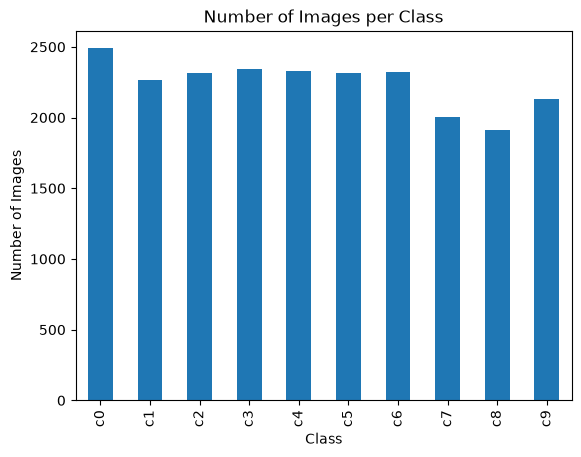

In [34]:
class_counts = df['classname'].value_counts().sort_index()

class_counts.plot(kind='bar')

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [37]:
df.groupby(['subject','classname'])['img'].count()

subject  classname
p002     c0           76
         c1           74
         c2           86
         c3           79
         c4           84
                      ..
p081     c5           81
         c6           79
         c7           77
         c8           61
         c9           80
Name: img, Length: 260, dtype: int64

In [39]:
df.groupby('subject').count()

,classname,img
subject,,
p002,725,725
p012,823,823
p014,876,876
p015,875,875
p016,1078,1078
p021,1237,1237
p022,1233,1233
p024,1226,1226
p026,1196,1196


In [50]:
df.groupby(['subject','classname']).count().reset_index()

,subject,classname,img
0,p002,c0,76
1,p002,c1,74
2,p002,c2,86
3,p002,c3,79
4,p002,c4,84
...,...,...,...
255,p081,c5,81
256,p081,c6,79
257,p081,c7,77
258,p081,c8,61


In [52]:
driver_class_counts = (
    df.groupby(['subject', 'classname'])['img']
    .count()
    .reset_index(name='image_count')
)
driver_class_counts

,subject,classname,image_count
0,p002,c0,76
1,p002,c1,74
2,p002,c2,86
3,p002,c3,79
4,p002,c4,84
...,...,...,...
255,p081,c5,81
256,p081,c6,79
257,p081,c7,77
258,p081,c8,61


In [53]:
class_counts = df['classname'].value_counts().sort_index()

print(class_counts)

classname
c0    2489
c1    2267
c2    2317
c3    2346
c4    2326
c5    2312
c6    2325
c7    2002
c8    1911
c9    2129
Name: count, dtype: int64


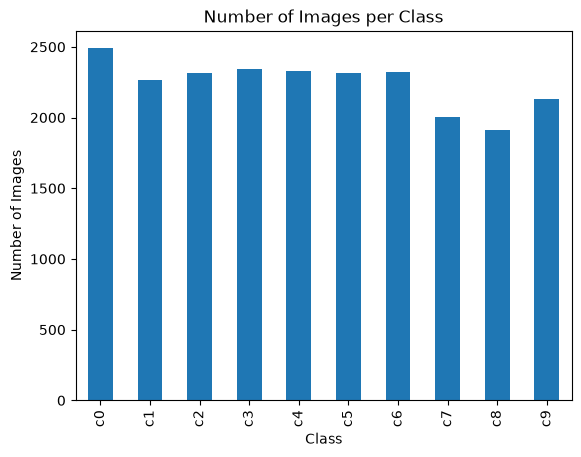

In [54]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [55]:
class_names = {
    'c0': 'Safe driving',
    'c1': 'Texting - right',
    'c2': 'Talking on phone - right',
    'c3': 'Texting - left',
    'c4': 'Talking on phone - left',
    'c5': 'Operating radio',
    'c6': 'Drinking',
    'c7': 'Reaching behind',
    'c8': 'Hair and makeup',
    'c9': 'Talking to passenger',
}

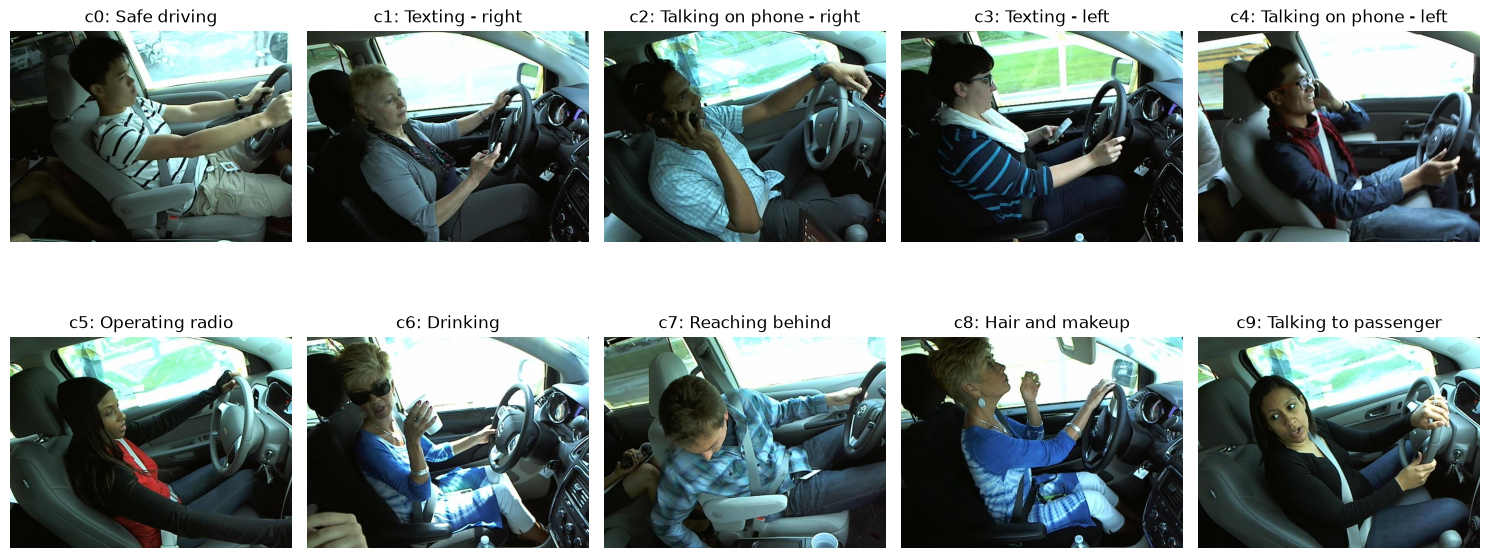

In [56]:
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for ax, class_name in zip(axes.flatten(), sorted(df['classname'].unique())):

    sample = df[df['classname'] == class_name].sample(1).iloc[0]

    image_path = (
        Path("../data/raw/imgs/train")
        / class_name
        / sample['img']
    )

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(f"{class_name}: {class_names[class_name]}")
    ax.axis('off')

plt.tight_layout()
plt.show()